# Experiment 7: Well-Conditioned vs Ill-Conditioned Matrices

Compare PALM and FISTA-PALM on matrices with different singular value spectra.

**Setup**
- Matrix size: $1000 \times 600$
- Rank: $r = 200$
- Sparsity in $Y$: $25\%$
- Conditions:
  - Well-conditioned: equal singular values
  - Ill-conditioned: exponentially decaying singular values
- Iterations: $100$

**Goal**

Evaluate how matrix conditioning affects the optimisation behaviour of PALM and FISTA-PALM.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.solvers.palm import PALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.data import create_matrix_with_conditioning, generate_initial_factors
from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.plotting import plot_conditioning_comparison
from src.utils.io import make_fig_path, save_table

In [2]:
np.random.seed(42)

m, n, r = 1000, 600, 200
sparsity = 0.25
max_iter = 100
gamma = 1.2

scales = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
conditions = ["well", "ill"]

condition_labels = {
    "well": "Well-conditioned",
    "ill": "Ill-conditioned",
}

solvers = {
    "PALM": PALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
}

## Run conditioning experiment

Generate well-conditioned and ill-conditioned matrices and compare objective values after $100$ iterations.

In [3]:
records = []

for condition in conditions:
    for scale in scales:
        A = create_matrix_with_conditioning(
            m,
            n,
            r,
            condition=condition,
            scale=scale,
            seed=42,
        )

        X0, Y0 = generate_initial_factors(
            m,
            n,
            r,
            seed=42,
        )

        problem = make_matrix_factorisation_problem(
            A,
            r,
            sparsity,
            gamma=gamma,
        )

        for method_name, solver in solvers.items():
            _, _, hist = solver.solve(problem, X0.copy(), Y0.copy())

            records.append({
                "Condition": condition_labels[condition],
                "Scale": scale,
                "Scale Label": f"{scale:.0e}",
                "Method": method_name,
                "Final Objective": hist[-1],
                "Iterations": len(hist) - 1,
            })

df = pd.DataFrame(records)

## Objective table

Final objective values for each method, scale, and conditioning regime.

In [4]:
params = {
    "m": m,
    "n": n,
    "r": r,
    "s": sparsity,
    "iter": max_iter,
}

save_table(
    df,
    ROOT,
    "conditioning_summary",
    params,
)

table = df.pivot_table(
    index=["Condition", "Scale Label"],
    columns="Method",
    values="Final Objective",
).reset_index()

display(
    table.style
    .set_caption("Objective Values at Iteration 100 for Well- and Ill-Conditioned Matrices")
    .format(precision=10)
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("text-align", "center"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
            ],
        }
    ])
    .highlight_min(
        subset=["PALM", "FISTA-PALM"],
        color="lightgreen",
        axis=1,
    )
    .set_properties(**{"text-align": "center"})
)

Condition,Scale Label,FISTA-PALM,PALM
Ill-conditioned,1e+01,270.0698159132,562.3576467078
Ill-conditioned,1e+02,24360.0085309993,33513.2461823602
Ill-conditioned,1e+03,2355568.2090640264,2518096.0609759563
Ill-conditioned,1e+04,234327626.2127043009,240893508.5293161869
Ill-conditioned,1e+05,23451828292.3061256409,24048986306.4669342041
Ill-conditioned,1e+06,2342897973371.7197265625,2408235197257.5234375000
Well-conditioned,1e+01,8715.7907557272,9905.1586681799
Well-conditioned,1e+02,817950.0373334835,913360.9961162981
Well-conditioned,1e+03,80415691.2143037468,85839099.9338791966
Well-conditioned,1e+04,8026059701.9546985626,8559207874.1422367096


## Conditioning comparison plot

Two-panel comparison between well-conditioned and ill-conditioned matrices.

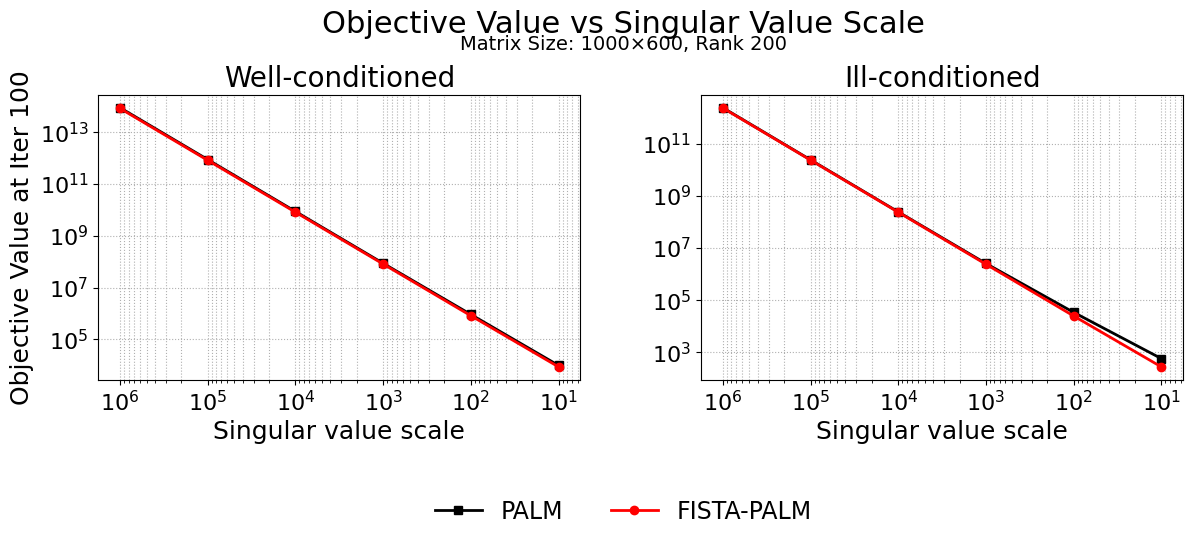

In [5]:
plot_conditioning_comparison(
    df,
    scales,
    title="Objective Value vs Singular Value Scale",
    subtitle=f"Matrix Size: {m}×{n}, Rank {r}",
    save_path=make_fig_path(ROOT, "conditioning_comparison", params),
)

## Observations

- In both conditioning regimes, the final objective increases systematically with the singular value scale, as expected from the increasing magnitude of the target matrix.

- In the well-conditioned case, PALM and FISTA-PALM behave almost identically across all scales. This suggests that when the singular values are uniform, acceleration does not substantially change the final objective after $100$ iterations.

- In the ill-conditioned case, FISTA-PALM consistently achieves a lower objective value than PALM across all scales.

- The gap between the methods is more visible for smaller scales in the ill-conditioned setting, where FISTA-PALM appears better able to exploit directions with weaker singular values.

- Overall, conditioning matters more than scale alone: when the spectrum is flat, both methods behave similarly, but when the spectrum is uneven, FISTA-PALM gains a clearer advantage.